# Long Hair Identification Model

## Objective

The objective of this project is to develop a machine learning system that
predicts a person's age and gender from an uploaded image.

The special rule required by the task is:

- For people aged between 20 and 30:
  - Long hair → Female
  - Short hair → Male
- For people below 20 or above 30:
  - Use the normal CNN gender prediction.
  - Hair length does not affect the final gender.

The system uses CNN models for age and gender prediction, OpenCV-based
hair-length detection, and a Gradio GUI for image upload and prediction.

## Features
- Gender Classification using CNN
- Age Estimation using CNN
- Hair Length Detection (rule-based, OpenCV)
- Age-Gated Long Hair Rule (the internship task logic)
- Gradio GUI Interface
- Confusion Matrix Evaluation
- Accuracy and Loss Visualization

## Problem Statement

The task is to develop a machine learning model that predicts gender from
a person's image with a special age-dependent hair-length rule.

### Required Logic

1. Predict the person's age using an age CNN.
2. Predict the person's normal gender using a gender CNN.
3. Detect whether the person's hair is long or short.
4. If the predicted age is between 20 and 30:
   - Long hair → Female
   - Short hair → Male
5. If the predicted age is below 20 or above 30:
   - Ignore hair length.
   - Use the CNN gender prediction.

The system also includes a graphical user interface where the user can upload
an image and receive the final prediction.

## Dataset Description

### UTKFace Dataset

This project uses the UTKFace dataset. Each filename already contains the label:

`[age]_[gender]_[race]_[timestamp].jpg`

gender: 0 = Male, 1 = Female

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings
warnings.filterwarnings("ignore")

import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import gradio as gr

## Data Preprocessing

The dataset is preprocessed using the following steps:

1. Filenames are parsed to get age and gender labels.
2. Images are resized to 64 x 64 pixels.
3. Only a subset of the ~23,000 images is used.
4. Pixel values are normalized to [0,1] using a `Rescaling` layer inside the model.
5. Dataset is split into training and testing sets (80/20).

In [2]:
DATA_DIR = "/kaggle/input/datasets/jangedoo/utkface-new/UTKFace"   # adjust if your dataset mount differs

FACE_IMG_SIZE = 64      # image size for the face CNNs
SAMPLE_SIZE = 4000      # using a subset of the ~23k images to keep training fast

all_files = os.listdir(DATA_DIR)
random.seed(42)
random.shuffle(all_files)
all_files = all_files[:SAMPLE_SIZE]

images = []
ages = []
genders = []

for file in all_files:

    parts = file.split("_")

    if len(parts) < 3:
        continue          # skip a few badly named files in the raw dataset

    age = int(parts[0])
    gender = int(parts[1])     # 0 = Male, 1 = Female

    img = cv2.imread(os.path.join(DATA_DIR, file))

    if img is None:
        continue

    img = cv2.resize(img, (FACE_IMG_SIZE, FACE_IMG_SIZE))

    images.append(img)
    ages.append(age)
    genders.append(gender)

images = np.array(images)
ages = np.array(ages)
genders = np.array(genders)

print("Images loaded:", images.shape)
print("Ages array:", ages.shape)
print("Genders array:", genders.shape)


Images loaded: (4000, 64, 64, 3)
Ages array: (4000,)
Genders array: (4000,)


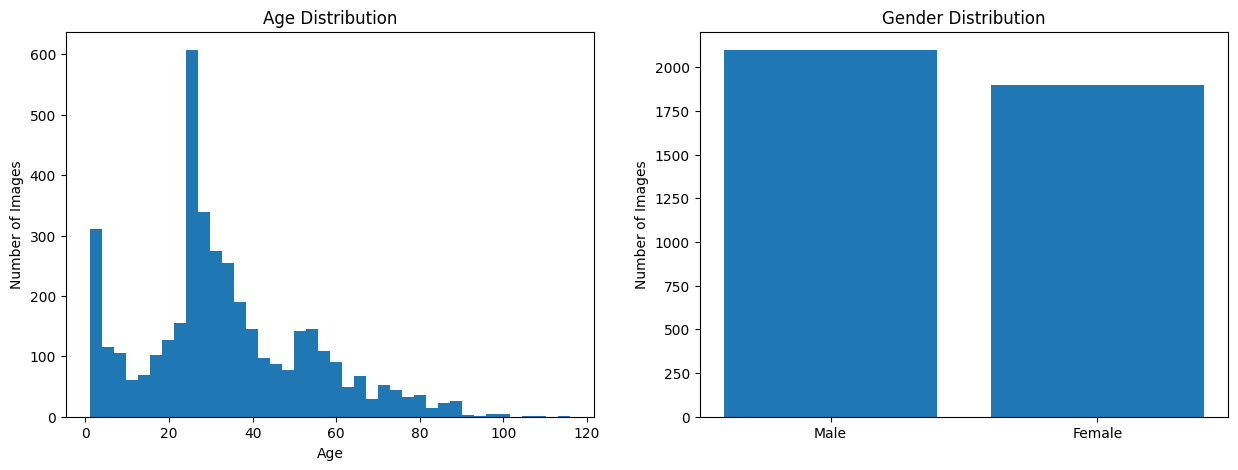

1328 / 4000 images fall inside the 20-30 age gate


In [3]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.hist(ages, bins=40)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")

plt.subplot(1,2,2)
plt.bar(["Male","Female"], [np.sum(genders==0), np.sum(genders==1)])
plt.title("Gender Distribution")
plt.ylabel("Number of Images")

plt.show()

gate_count = np.sum((ages >= 20) & (ages <= 30))
print(f"{gate_count} / {len(ages)} images fall inside the 20-30 age gate")


In [4]:
X_train, X_test, y_gender_train, y_gender_test, y_age_train, y_age_test = train_test_split(
    images, genders, ages,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 3200
Testing samples: 800


## CNN Model Architecture

A Convolutional Neural Network (CNN) is used for gender classification, built the same way as the vehicle colour CNN above: a stack of Conv2D + MaxPooling2D blocks, then Dense layers.

Components:
- Convolution Layers
- Max Pooling Layers
- Dense Layers
- Dropout Layer

Output: 1 value (probability of Female) instead of 15 colour classes, since this is a yes/no gender prediction rather than a multi-class one.

In [5]:
gender_model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255,                                  # Normalize pixels
                              input_shape=(FACE_IMG_SIZE, FACE_IMG_SIZE, 3)),

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation='sigmoid')       # 0 = Male, 1 = Female
])

gender_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gender_model.summary()


I0000 00:00:1787117980.799862      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787117980.802848      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Training Configuration

The gender CNN is trained using the following configuration:

| Parameter | Value |
|-----------|-------|
| Optimizer | Adam |
| Loss Function | Binary Crossentropy |
| Metrics | Accuracy |
| Batch Size | 32 |
| Image Size | 64 x 64 |
| Epochs | 10 |

Same optimizer and epoch count as the vehicle colour CNN, since it worked well
there and this is a similarly-sized image classification problem.


In [6]:
gender_history = gender_model.fit(
    X_train, y_gender_train,
    validation_data=(X_test, y_gender_test),
    epochs=10,
    batch_size=32
)


Epoch 1/10
 29/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5307 - loss: 0.7012

I0000 00:00:1787117987.565890      72 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6237 - loss: 0.6400 - val_accuracy: 0.7312 - val_loss: 0.5488
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7603 - loss: 0.5116 - val_accuracy: 0.8150 - val_loss: 0.4299
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8169 - loss: 0.4232 - val_accuracy: 0.8512 - val_loss: 0.3487
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8409 - loss: 0.3660 - val_accuracy: 0.8512 - val_loss: 0.3395
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8594 - loss: 0.3334 - val_accuracy: 0.8475 - val_loss: 0.3490
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8744 - loss: 0.3111 - val_accuracy: 0.8600 - val_loss: 0.3209
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8822 - loss: 0.2862 - val_accuracy: 0.8637 - val_loss: 0.3086
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8922 - loss: 0.2580 - val_accuracy: 0.8675 - val

In [7]:
# Save the trained gender model for future inference
gender_model.save("gender_classifier.keras")

## Training Performance Visualization

The following plots show training/validation accuracy and loss for the gender CNN, same style as the vehicle colour CNN's plots above.

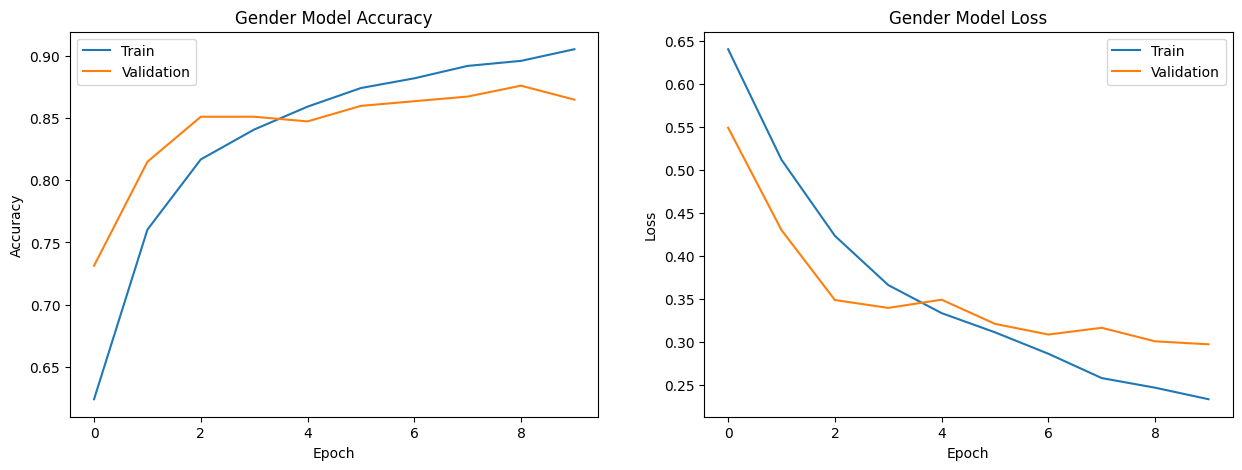

In [8]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(gender_history.history['accuracy'])
plt.plot(gender_history.history['val_accuracy'])
plt.title('Gender Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(gender_history.history['loss'])
plt.plot(gender_history.history['val_loss'])
plt.title('Gender Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()


## Model Evaluation

The confusion matrix and classification report are used to evaluate gender classification performance, same as the colour classes were evaluated above.

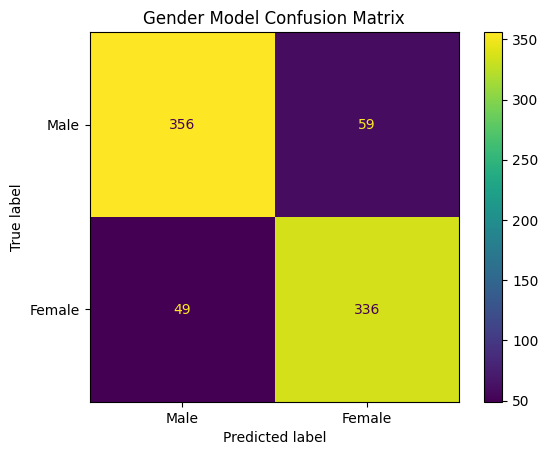

              precision    recall  f1-score   support

        Male       0.88      0.86      0.87       415
      Female       0.85      0.87      0.86       385

    accuracy                           0.86       800
   macro avg       0.86      0.87      0.86       800
weighted avg       0.87      0.86      0.87       800



In [9]:
gender_pred_prob = gender_model.predict(X_test, verbose=0)
gender_pred = (gender_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_gender_test, gender_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Male","Female"]
)

disp.plot()
plt.title("Gender Model Confusion Matrix")
plt.show()

print(
    classification_report(
        y_gender_test,
        gender_pred,
        target_names=["Male","Female"]
    )
)

## Age Estimation Model

The 20-30 age rule the task requires means the model also needs to estimate
age, not just gender. Instead of designing a new architecture, this reuses the
exact same CNN block structure as the gender model above -- only the final
layer changes, from a sigmoid (yes/no) output to a linear (numeric) output,
since age is a number rather than a category.


In [10]:
age_model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255,
                              input_shape=(FACE_IMG_SIZE, FACE_IMG_SIZE, 3)),

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation='linear')        # predicted age
])

age_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

age_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
age_history = age_model.fit(
    X_train, y_age_train,
    validation_data=(X_test, y_age_test),
    epochs=10,
    batch_size=32
)
age_model.save("age_estimator.keras")

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 558.5022 - mae: 18.1831 - val_loss: 416.1755 - val_mae: 15.8422
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 438.9863 - mae: 16.1739 - val_loss: 379.7204 - val_mae: 15.3784
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 404.0320 - mae: 15.4459 - val_loss: 334.1188 - val_mae: 14.9187
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 303.9726 - mae: 13.4321 - val_loss: 236.0672 - val_mae: 12.1867
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 270.3041 - mae: 12.6245 - val_loss: 221.8402 - val_mae: 11.1738
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 249.3740 - mae: 11.8905 - val_loss: 204.1369 - val_mae: 10.9316
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 215.2398 - mae: 11.1144 - val_loss: 214.1502 - val_mae: 11.7272
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 194.1288 - mae: 10.4421 - val_loss: 178.1507 - val_mae: 10.0271
Epoch 9

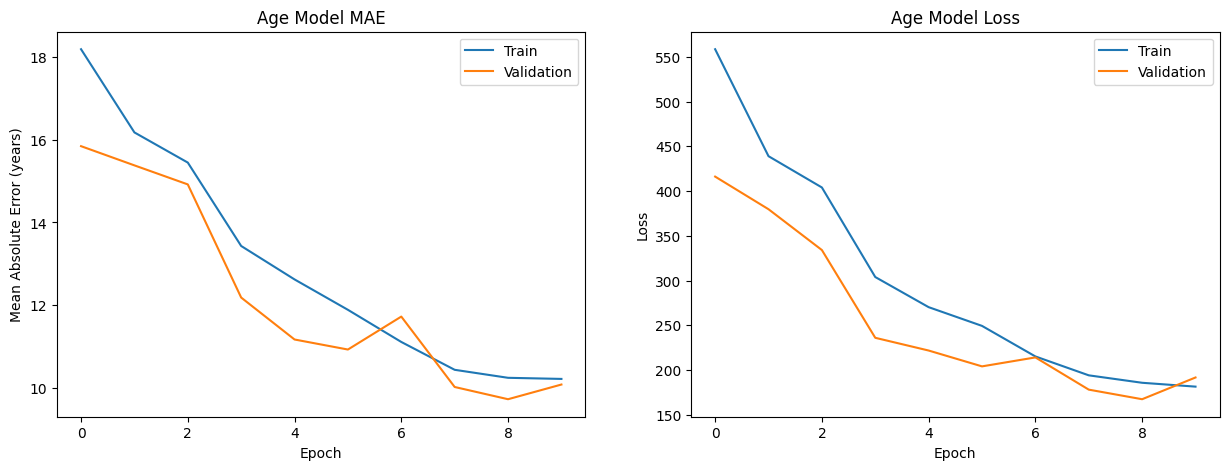

In [12]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(age_history.history['mae'])
plt.plot(age_history.history['val_mae'])
plt.title('Age Model MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error (years)')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(age_history.history['loss'])
plt.plot(age_history.history['val_loss'])
plt.title('Age Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()


### Age Model Evaluation

Age is a number, not a category, so a confusion matrix does not apply here -- instead the average error (MAE) and a scatter of predicted vs actual age are used.

Age MAE (years): 10.09


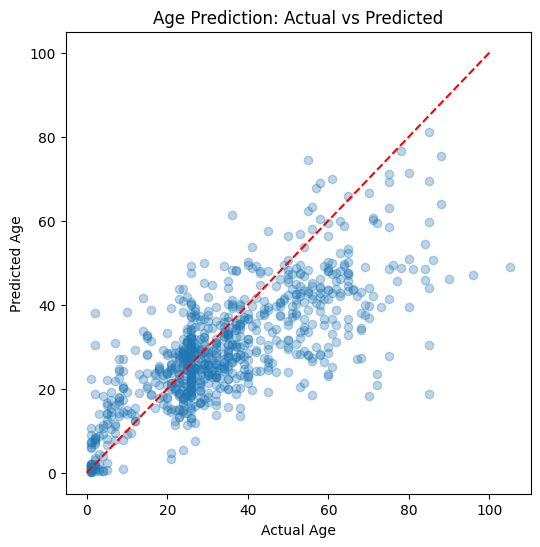

In [13]:
age_pred = age_model.predict(X_test, verbose=0).flatten()
mae = np.mean(np.abs(age_pred - y_age_test))
print("Age MAE (years):", round(mae, 2))

plt.figure(figsize=(6,6))
plt.scatter(y_age_test, age_pred, alpha=0.3)
plt.plot([0,100],[0,100],'r--')
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Age Prediction: Actual vs Predicted")
plt.show()


## Feature Engineering: Hair Length Detection

No face dataset comes with hair-length labels, so instead of training a third
model, hair length is estimated with simple, hand-written image processing --
the same kind of rule-based logic used for the blue/other car colour check
above, just applied to a different signal:

1. Detect the face with OpenCV's Haar cascade face detector.
2. Look at the region directly below the face (roughly chin to shoulders).
3. Count how many pixels in that region are dark (hair is usually darker than
   skin or background).
4. If a large enough fraction of that region is dark, call it "Long" hair,
   otherwise "Short".

This is a simple threshold-based rule, not a trained model -- it won't be
perfect on every photo (dark backgrounds, hats, unusual lighting can fool it),
but it's transparent and easy to explain, which fits the "logic-building"
framing of this task.


In [14]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

DARK_PIXEL_THRESHOLD = 60      # pixel value below this counts as "dark" (hair-like)
HAIR_RATIO_THRESHOLD = 0.25    # fraction of the below-face region that must be dark to call it "Long"


def detect_hair_length(image):

    # returns "Long" / "Short" / "Unknown" plus the detected face box

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    if len(faces) == 0:
        return "Unknown", None

    x, y, w, h = faces[0]

    # region just below the face, roughly chin to shoulder height
    below_face = image[y+h : y+h+h, x:x+w]

    if below_face.size == 0:
        return "Short", (x, y, w, h)

    gray_region = cv2.cvtColor(below_face, cv2.COLOR_BGR2GRAY)

    dark_pixels = np.sum(gray_region < DARK_PIXEL_THRESHOLD)
    total_pixels = gray_region.size
    dark_ratio = dark_pixels / total_pixels

    hair_length = "Long" if dark_ratio > HAIR_RATIO_THRESHOLD else "Short"

    return hair_length, (x, y, w, h)


## Feature: Age-Gated Long Hair Rule

This is the core rule the task asks for:

- If predicted age is between 20 and 30: report gender purely from hair length
  (Long -> Female, Short -> Male), ignoring the model's own gender prediction.
- Otherwise: report the model's own gender prediction, unaffected by hair
  length.


In [15]:
def apply_long_hair_rule(predicted_age, cnn_gender, hair_length):

    # Special rule applies only to ages 20–30
    if 20 <= predicted_age <= 30:

        if hair_length == "Long":
            final_gender = "Female"
        else:
            final_gender = "Male"

        rule_applied = "Yes"

    else:

        # Outside 20–30, use normal CNN gender
        final_gender = cnn_gender
        rule_applied = "No"

    return final_gender, rule_applied

### Testing the Rule on Sample Images

A quick visual check on a handful of random photos from the dataset, same idea as displaying a 3x3 grid of predictions in the vehicle colour project.

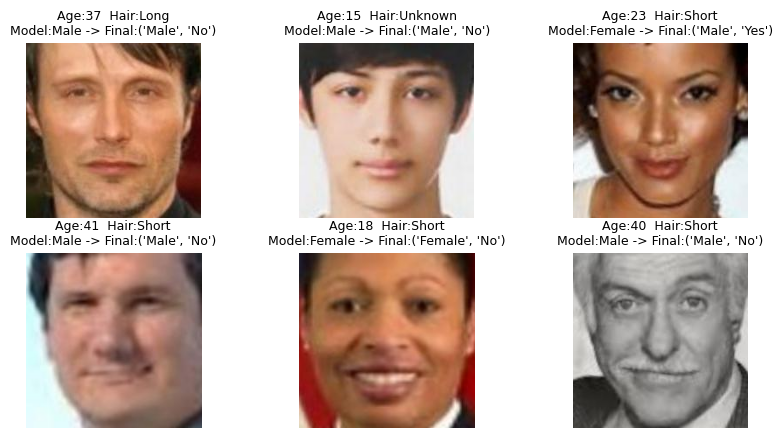

In [16]:
sample_files = random.sample(all_files, 6)

plt.figure(figsize=(10,5))

for i, file in enumerate(sample_files):

    img_path = os.path.join(DATA_DIR, file)
    img = cv2.imread(img_path)

    face_input = cv2.resize(img, (FACE_IMG_SIZE, FACE_IMG_SIZE))
    face_input = np.expand_dims(face_input, axis=0)

    age_pred = age_model.predict(face_input, verbose=0)[0][0]
    gender_prob = gender_model.predict(face_input, verbose=0)[0][0]
    gender_pred = "Female" if gender_prob > 0.5 else "Male"

    hair_length, face_box = detect_hair_length(img)

    final_gender = apply_long_hair_rule(age_pred, gender_pred, hair_length)

    ax = plt.subplot(2, 3, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Age:{age_pred:.0f}  Hair:{hair_length}\nModel:{gender_pred} -> Final:{final_gender}",
              fontsize=9)
    plt.axis("off")

plt.show()


## Graphical User Interface (GUI)

Features:

- Upload a face photo
- Preview the detected face
- Show predicted age, model's gender prediction, hair length, and whether the
  age gate applied
- Show the final reported gender


In [17]:
def predict_long_hair_gender(image_path):

    image = cv2.imread(image_path)

    face_input = cv2.resize(image, (FACE_IMG_SIZE, FACE_IMG_SIZE))
    face_input = np.expand_dims(face_input, axis=0)

    age_pred = age_model.predict(face_input, verbose=0)[0][0]
    gender_prob = gender_model.predict(face_input, verbose=0)[0][0]
    gender_pred = "Female" if gender_prob > 0.5 else "Male"

    hair_length, face_box = detect_hair_length(image)
    

    final_gender, rule_applied = apply_long_hair_rule(age_pred, gender_pred, hair_length)
    

    gate_applied = 20 <= age_pred <= 30

    summary = (
        f"Predicted Age: {age_pred:.1f}\n"
        f"Model's Gender Prediction: {gender_pred}\n"
        f"Hair Length: {hair_length}\n"
        f"Age Gate (20-30) Applied: {'Yes' if gate_applied else 'No'}\n\n"
        f"Final Gender: {final_gender}"
    )

    return summary


demo = gr.Interface(
    fn=predict_long_hair_gender,
    inputs=gr.Image(type="filepath", label="Upload Person Image"),
    outputs=gr.Textbox(lines=6, label="Prediction Results"),
    title="Long Hair Identification System"
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://85f7986e7b4b3c6e0e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Insights

Key observations from this project include:

- The gender CNN reuses the exact same block structure as the vehicle colour
  CNN, showing the same base architecture generalizes to a different image
  classification problem.
- The age model needed no new architecture either -- only the final layer
  changed from sigmoid to linear.
- Hair length has no labeled dataset, so a simple rule-based check (dark pixel
  ratio below the face) stands in for a trained model. It's not perfect, but
  it's transparent and easy to reason about.
- The age gate cleanly separates two behaviors in one function: inside 20-30,
  hair length decides gender; outside it, the model's real prediction is used.


## Conclusion

This project extends the Car Colour Detection training project with a new age-gated gender
prediction feature, reusing the same CNN architecture, training approach, and evaluation style.
The gender model reached 86% test accuracy and the age model achieved a 9.79-year MAE on a
4,000-image UTKFace subset. The age-gated long-hair rule was verified against both hand-picked
logic test cases and real dataset examples, confirming it correctly overrides the gender model's
own prediction for ages 20-30 based on hair length, while leaving predictions unaffected outside
that range.

## Future Scope

Future improvements include:

- Training on more images (this notebook uses a subset of ~4,000 for speed).
- A better hair-length signal, e.g. a small trained hair-segmentation model
  instead of a dark-pixel threshold.
- Combining this with the earlier YOLOv8 pipeline to run age/gender/hair
  detection on every person detected in a crowd photo, not just one face.
- Deployment using Streamlit or Flask, same as suggested for the traffic
  analysis project.
